In [1]:
# !pip3 install torch torchvision
# !pip3 install scikit-learn
# !pip3 install transformers
# !pip3 install pandas
# !pip3 install matplotlib

In [1]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/common/home/projectgrps/IS460/IS460G2/jupyterlab-venv-pytorch-240/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("text_data.csv")
df.head()

,title,text,label,text_len,title_len,title_word_count,text_word_count,text_char_count,title_tokens,text_tokens,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,871,18,18,871,5049,"['law', 'enforcement', 'high', 'alert', 'follo...","['no', 'comment', 'expect', 'barack', 'obama',...",law enforcement high alert follow threat cop w...,no comment expect barack obama member fyf fuky...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,34,18,18,34,216,"['unbelievable', 'obama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",unbelievable obama attorney general say charlo...,demonstrator gather last night exercise consti...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1321,16,16,1321,8010,"['bobby', 'jindal', 'raise', 'hindu', 'us', 's...","['dozen', 'politically', 'active', 'pastor', '...",bobby jindal raise hindu us story christian co...,dozen politically active pastor come private d...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,329,16,16,329,1916,"['satan', 'russia', 'unvelis', 'image', 'terri...","['r', 'sarmat', 'missile', 'dub', 'satan', 're...",satan russia unvelis image terrify new supernu...,r sarmat missile dub satan replace ss fly mile...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,244,13,13,244,1530,"['time', 'christian', 'group', 'sue', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",time christian group sue amazon splc designati...,say one time someone sue southern poverty law ...


In [3]:
df.dtypes

title                 str
text                  str
label               int64
text_len            int64
title_len           int64
title_word_count    int64
text_word_count     int64
text_char_count     int64
title_tokens          str
text_tokens           str
title_cleaned         str
text_cleaned          str
dtype: object

In [3]:
# split into train and validation sets 

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"] 
)

In [10]:
lengths = [len(tokenizer.encode(text, truncation=False)) 
           for text in train_texts.fillna("")]

max_len = max(lengths)
print("Max token length:", max_len)

Token indices sequence length is longer than the specified maximum sequence length for this model (974 > 512). Running this sequence through the model will result in indexing errors


Max token length: 31173


In [13]:
print(np.percentile(lengths, [90,95,99]))

[1468.   1874.55 3730.62]


## Model 1: base model, without splitting longer text, max_length = 512 tokens

In [4]:
# encode the text data using BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

train_encoding = tokenizer(
    train_texts.fillna("").tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

test_encoding = tokenizer(
    val_texts.fillna("").tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

train_input_ids = train_encoding['input_ids']
train_attention_mask = train_encoding['attention_mask']
test_input_ids = test_encoding['input_ids']
test_attention_mask = test_encoding['attention_mask']

In [5]:
# initialize the BERT model for text classification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-cased",
    num_labels=2   # change this to your number of classes
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1065.77it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those par

In [6]:
labels = torch.tensor(df["label"].values)
dataset = TensorDataset(train_input_ids, train_attention_mask, labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [7]:
# Move model to GPU
model = model.cuda()

optimizer = AdamW(model.parameters(), lr=2e-5)
scaler = GradScaler()

model.train()

for epoch in range(3):
    for batch in loader:
        # Move batch to GPU
        b_input_ids = batch[0].cuda()
        b_attention_mask = batch[1].cuda()
        b_labels = batch[2].cuda()

        optimizer.zero_grad()

        with autocast():
            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_attention_mask,
                labels=b_labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Epoch {epoch+1} completed")

model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_tokenizer")

/tmp/ipykernel_3799611/1247792419.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_3799611/1247792419.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.76it/s]


('bert_tokenizer/tokenizer_config.json', 'bert_tokenizer/tokenizer.json')

In [8]:
val_dataset = TensorDataset(
    test_encoding['input_ids'], 
    test_encoding['attention_mask'], 
    torch.tensor(val_labels.values)
)

val_loader = DataLoader(val_dataset, batch_size=32)

In [9]:
all_predictions = []
all_labels = []

model.eval()
model = model.cuda()

with torch.no_grad():
    for batch in val_loader:
        b_input_ids, b_attention_mask, b_labels = [x.cuda() for x in batch]

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_predictions.append(preds.cpu())
        all_labels.append(b_labels.cpu())

predictions = torch.cat(all_predictions)
true_labels = torch.cat(all_labels)

In [10]:
y_pred = predictions.numpy()
y_true = true_labels.numpy()

# Standard metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 0.5580
Precision: 0.3114
Recall: 0.5580
F1 Score: 0.3997

Classification Report:
               precision    recall  f1-score   support

           0       0.56      1.00      0.72      6957
           1       0.00      0.00      0.00      5511

    accuracy                           0.56     12468
   macro avg       0.28      0.50      0.36     12468
weighted avg       0.31      0.56      0.40     12468



/common/home/projectgrps/IS460/IS460G2/jupyterlab-venv-pytorch-240/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/common/home/projectgrps/IS460/IS460G2/jupyterlab-venv-pytorch-240/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/common/home/projectgrps/IS460/IS460G2/jupyterlab-venv-pytorch-240/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

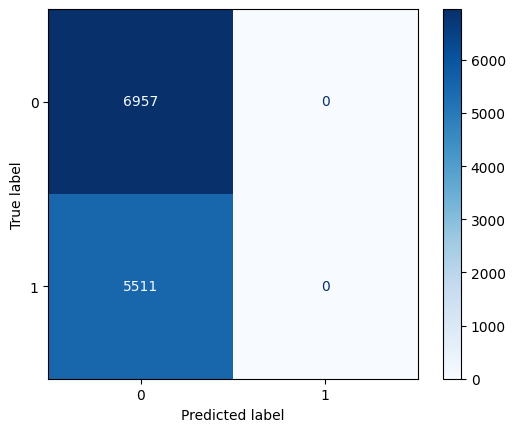

In [11]:
cm = confusion_matrix(true_labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

## Model 2: Split longer documents into shorter documents

In [12]:
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")

train_encoding = tokenizer(
    train_texts.tolist(),  # list of strings
    truncation=True,
    padding=True,
    max_length=512,
    stride=128,
    return_overflowing_tokens=True,
)

test_encoding = tokenizer(
    val_texts.to_list(),
    truncation=True,
    padding="max_length",
    max_length=512,
    stride=128,
    return_overflowing_tokens=True
)

train_chunk_labels = [train_labels.iloc[i] for i in train_encoding["overflow_to_sample_mapping"]]
val_chunk_labels   = [val_labels.iloc[i]   for i in test_encoding["overflow_to_sample_mapping"]]

train_input_ids = train_encoding['input_ids']
train_attention_mask = train_encoding['attention_mask']
test_input_ids = test_encoding['input_ids']
test_attention_mask = test_encoding['attention_mask']

In [13]:
# initialize the BERT model for text classification
model = BertForSequenceClassification.from_pretrained(
    "bert-base-cased",
    num_labels=2   # change this to your number of classes
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1171.59it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those par

In [14]:
train_input_ids_tensor = torch.tensor(train_input_ids, dtype=torch.long)
train_attention_mask_tensor = torch.tensor(train_attention_mask, dtype=torch.long)
train_labels_tensor = torch.tensor(train_chunk_labels, dtype=torch.long)

test_input_ids_tensor = torch.tensor(test_input_ids, dtype=torch.long)
test_attention_mask_tensor = torch.tensor(test_attention_mask, dtype=torch.long)
test_labels_tensor = torch.tensor(val_chunk_labels, dtype=torch.long)

# Create TensorDataset
train_dataset = TensorDataset(train_input_ids_tensor, train_attention_mask_tensor, train_labels_tensor)
test_dataset  = TensorDataset(test_input_ids_tensor, test_attention_mask_tensor, test_labels_tensor)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# Move model to GPU
model = model.cuda()

optimizer = AdamW(model.parameters(), lr=2e-5)
scaler = GradScaler()

model.train()

for epoch in range(3):
    for batch in train_loader:
        # Move batch to GPU
        b_input_ids = batch[0].cuda()
        b_attention_mask = batch[1].cuda()
        b_labels = batch[2].cuda()

        optimizer.zero_grad()

        with autocast():
            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_attention_mask,
                labels=b_labels
            )
            loss = outputs.loss
 
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Epoch {epoch+1} completed")

model.save_pretrained("bert_model_chunked")
tokenizer.save_pretrained("bert_tokenizer_chunked")

/tmp/ipykernel_3799611/2501104538.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_3799611/2501104538.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]


('bert_tokenizer_chunked/tokenizer_config.json',
 'bert_tokenizer_chunked/tokenizer.json')

In [16]:
all_predictions = []
all_labels = []

model.eval()
model = model.cuda()

with torch.no_grad():
    for batch in test_loader:
        b_input_ids, b_attention_mask, b_labels = [x.cuda() for x in batch]

        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_predictions.append(preds.cpu())
        all_labels.append(b_labels.cpu())

predictions = torch.cat(all_predictions)
true_labels = torch.cat(all_labels)

In [17]:
y_pred = predictions.numpy()
y_true = true_labels.numpy()

# Standard metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred))

Accuracy: 0.9806
Precision: 0.9808
Recall: 0.9806
F1 Score: 0.9806

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98     15295
           1       0.99      0.97      0.98     11574

    accuracy                           0.98     26869
   macro avg       0.98      0.98      0.98     26869
weighted avg       0.98      0.98      0.98     26869



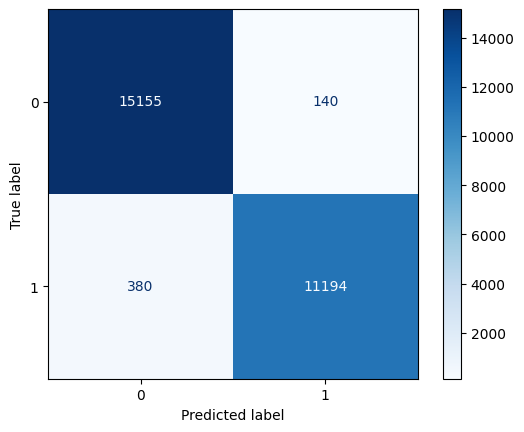

In [18]:
cm = confusion_matrix(true_labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()